In [29]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr, spearmanr

# Set aesthetic styling for the plots
sns.set_theme(style="whitegrid")

In [ ]:
# Run this if using Gemini version
# Change to desatirized for the other direction
file_path = '../data/silver-gemini/scored_satirized_headlines.json'

with open(file_path, 'r') as f:
    data = json.load(f)

print(f"Loaded {len(data)} original headlines.")

# Flatten the data structure
rows = []
for entry in data:
    original = entry.get('original_headline', '')
    candidates = entry.get('candidates', [])
    
    for cand in candidates:
        rows.append({
            'original_headline': original,
            'candidate_text': cand.get('candidate', cand.get('text', '')),
            'content_score': cand.get('content_score', None),
            'style_score': cand.get('style_score', None)
        })

df = pd.DataFrame(rows)

# Drop any rows where scores might be missing
df = df.dropna(subset=['content_score', 'style_score'])

print(f"Total candidate headlines for analysis: {len(df)}")
display(df.head())

In [18]:
# Run this if using previous version
# Change to desatirized for the other direction
file_path = '../data/silver/desarcastic_headlines_complete.txt'
df = pd.read_json(file_path, lines=True)

print(f"Total candidate headlines for analysis: {len(df)}")

# Rename columns for clarity
df.rename(columns={'non_sarcasm_score': "style_score"}, inplace=True)

display(df.head())

Total candidate headlines for analysis: 11684


,original_sarcastic_headline,silver_factual_headline,style_score,content_score,confidence_score
0,mom starting to fear son's web series closest ...,Son's Online Production Sparks Maternal Concer...,0.6582,0.0464,0.3523
1,"boehner just wants wife to listen, not come up...",US House Speaker's Spouse Weighs-In on Economi...,0.9647,0.1001,0.5324
2,top snake handler leaves sinking huckabee camp...,Former Campaign Manager Leaves Huckabee Presid...,0.8412,0.3552,0.5982
3,nuclear bomb detonates during rehearsal for 's...,Nuclear Bomb Detonates During Theater Practice,0.3178,0.5388,0.4283
4,"stock analysts confused, frightened by boar ma...",Market Turbulence Causes Concern Among Financi...,0.8622,0.2449,0.5535


,content_score,style_score
count,11684.000000,11684.000000
mean,0.273845,0.498892
std,0.157781,0.345171
min,-0.293700,0.006900
25%,0.162975,0.163575
50%,0.268500,0.469950
75%,0.378300,0.861100
max,0.892000,0.997100


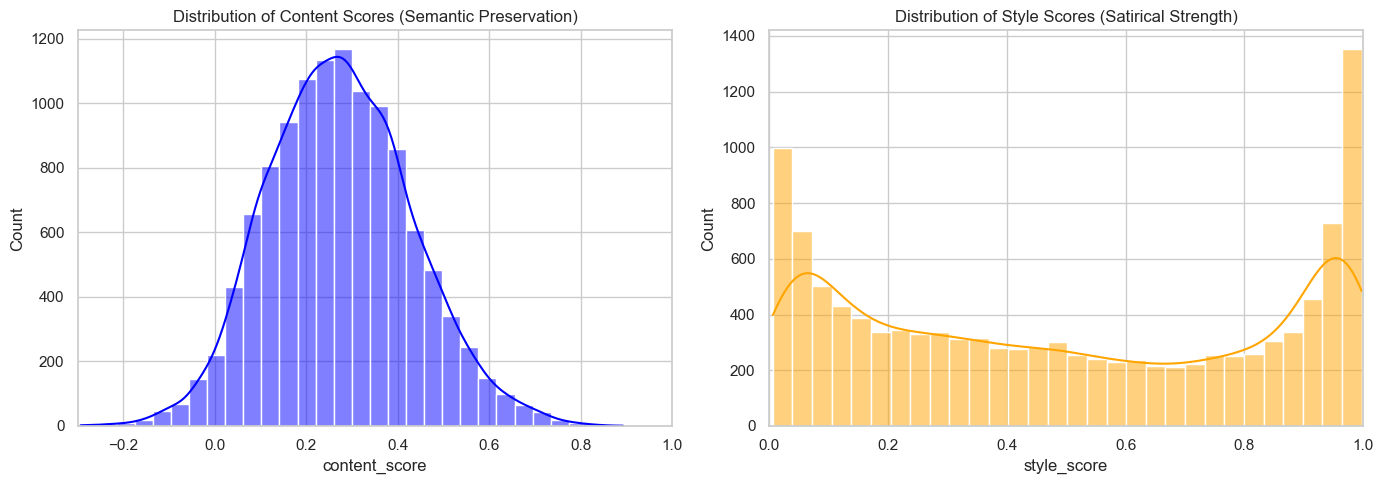

In [19]:
# Display summary statistics for the scores
display(df[['content_score', 'style_score']].describe())

# Plot the individual distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['content_score'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Content Scores (Semantic Preservation)')
axes[0].set_xlim(-0.3, 1)

sns.histplot(df['style_score'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution of Style Scores (Satirical Strength)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

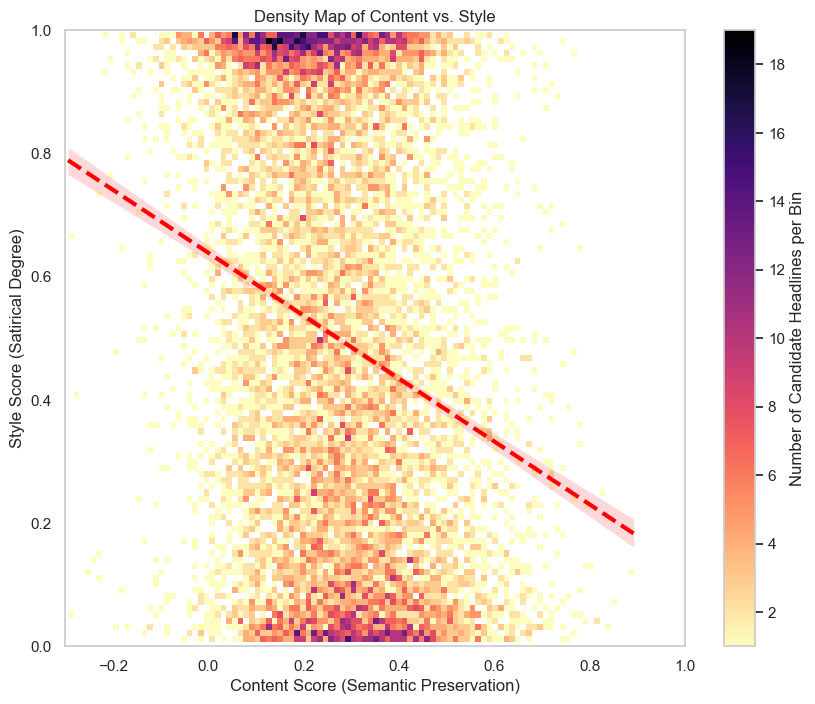

In [28]:
# Use a 2D histogram to efficiently map density for 200k points
plt.figure(figsize=(10, 8))

# bins=100 creates a 100x100 grid. cmin=1 makes completely empty bins transparent.
h = plt.hist2d(
    df['content_score'], 
    df['style_score'], 
    bins=100, 
    cmap='magma_r', # A good colormap for density
    cmin=1 
)
sns.regplot(
    data=df, 
    x='content_score', 
    y='style_score', 
    scatter=False, 
    color='red', 
    line_kws={'linewidth': 3, 'linestyle': '--'},
    label='Linear Regression Trend'
)
# Add a colorbar to show the scale of the point counts
plt.colorbar(h[3], label='Number of Candidate Headlines per Bin')

plt.title('Density Map of Content vs. Style')
plt.xlabel('Content Score (Semantic Preservation)')
plt.ylabel('Style Score (Satirical Degree)')
plt.xlim(-0.3, 1)
plt.ylim(0, 1)
plt.grid(False) # Turn off gridlines for cleaner density map
plt.show()

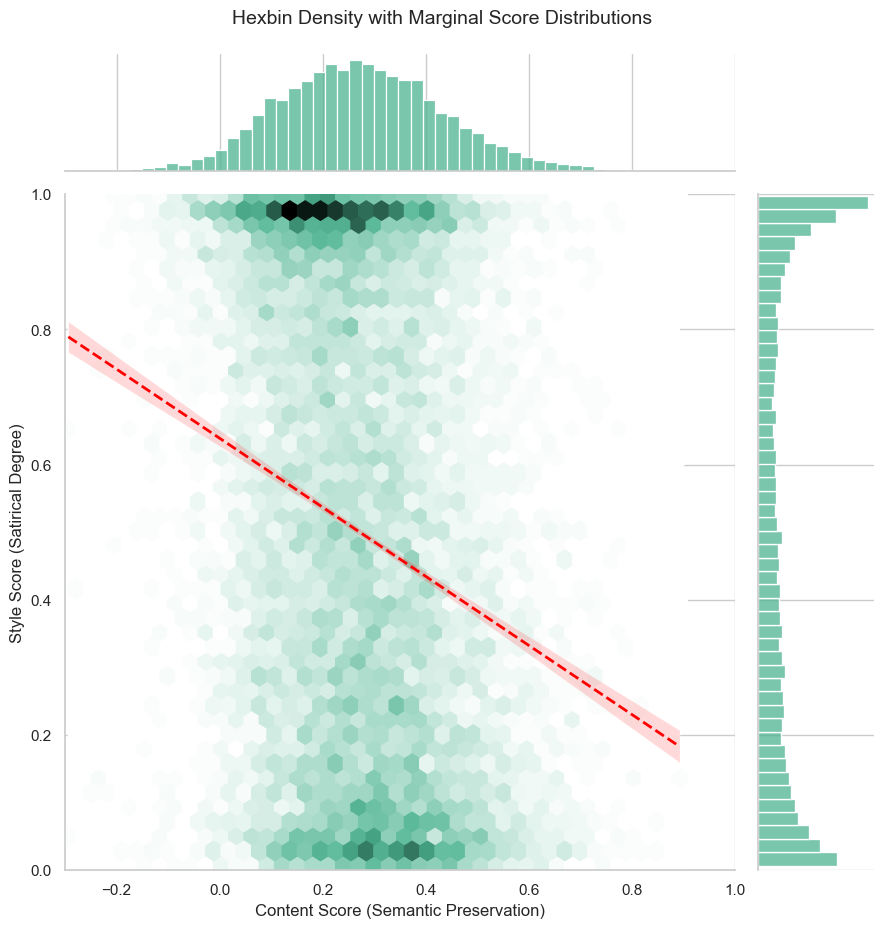

In [ ]:
# Create a hexbin jointplot
g = sns.jointplot(
    data=df, 
    x='content_score', 
    y='style_score', 
    kind="hex", 
    color="#4CB391",
    gridsize=40, # Number of hexagons in the x-direction
    xlim=(-0.3, 1),
    ylim=(0, 1),
    height=9,
    marginal_kws=dict(bins=50, fill=True) # More bins for the side histograms
)

sns.regplot(
    data=df, 
    x='content_score', 
    y='style_score', 
    scatter=False, # Turn off points, we only want the line
    ax=g.ax_joint, # Target the central hexbin plot
    line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'}
)

g.figure.suptitle('Hexbin Density with Marginal Score Distributions', y=1.03, fontsize=14)
g.set_axis_labels('Content Score (Semantic Preservation)', 'Style Score (Satirical Degree)')
plt.show()

In [30]:
# Calculate correlation coefficients
pearson_corr, p_value_p = pearsonr(df['content_score'], df['style_score'])
spearman_corr, p_value_s = spearmanr(df['content_score'], df['style_score'])

print(f"Pearson Correlation:  {pearson_corr:.4f} (p-value: {p_value_p:.4e})")
print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_value_s:.4e})")

slope, intercept = np.polyfit(df['content_score'], df['style_score'], 1)

# Format the equation string for the legend and printout
equation_str = f"y = {slope:.4f}x + {intercept:.4f}"

print(f"Regression Line Equation: {equation_str}")

if pearson_corr < -0.3:
    print("\nConclusion: There is a notable trade-off. As headlines become more satirical, they lose their original semantic meaning.")
elif pearson_corr > 0.3:
    print("\nConclusion: Unexpected result. The model seems to increase satire while better preserving semantics.")
else:
    print("\nConclusion: The relationship is weak or non-existent. The model's satire generation might be largely independent of semantic preservation.")

Pearson Correlation:  -0.2335 (p-value: 1.6768e-144)
Spearman Correlation: -0.2303 (p-value: 1.7903e-140)
Regression Line Equation: y = -0.5109x + 0.6388

Conclusion: The relationship is weak or non-existent. The model's satire generation might be largely independent of semantic preservation.
